In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/content/retail_sales_dataset.xlsx")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

df.info()

Shape: (1000, 9)

Data Types:
Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null  

In [4]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

In [5]:
print(df.describe())

print("\nMedian")
print(df.median(numeric_only=True))

print("\nMode")
print(df.mode().iloc[0])

print("\nStandard Deviation")
print(df.std(numeric_only=True))

       Transaction ID                           Date         Age     Quantity  \
count     1000.000000                           1000  1000.00000  1000.000000   
mean       500.500000  2023-07-03 00:25:55.200000256    41.39200     2.514000   
min          1.000000            2023-01-01 00:00:00    18.00000     1.000000   
25%        250.750000            2023-04-08 00:00:00    29.00000     1.000000   
50%        500.500000            2023-06-29 12:00:00    42.00000     3.000000   
75%        750.250000            2023-10-04 00:00:00    53.00000     4.000000   
max       1000.000000            2024-01-01 00:00:00    64.00000     4.000000   
std        288.819436                            NaN    13.68143     1.132734   

       Price per Unit  Total Amount  
count     1000.000000   1000.000000  
mean       179.890000    456.000000  
min         25.000000     25.000000  
25%         30.000000     60.000000  
50%         50.000000    135.000000  
75%        300.000000    900.000000  
max 

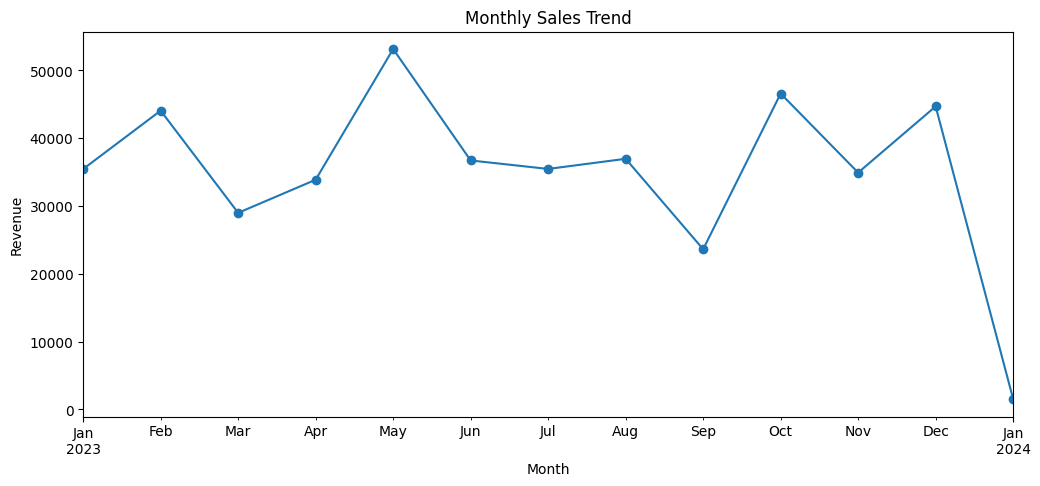

In [6]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

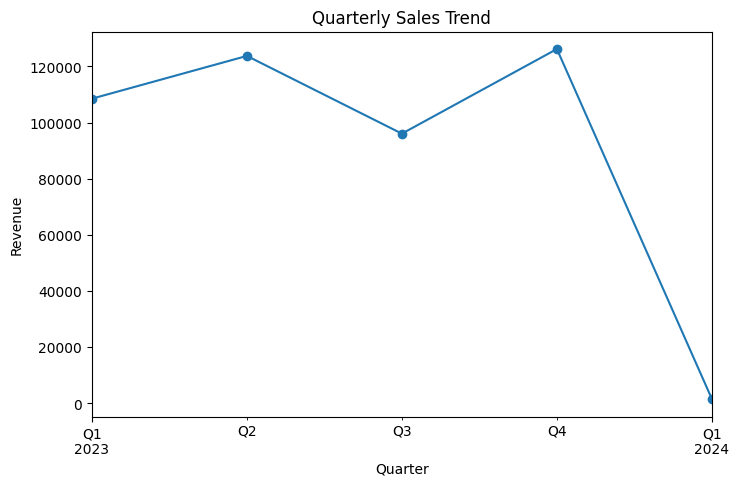

In [7]:
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

plt.figure(figsize=(8,5))
quarterly_sales.plot(marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Revenue')

plt.show()

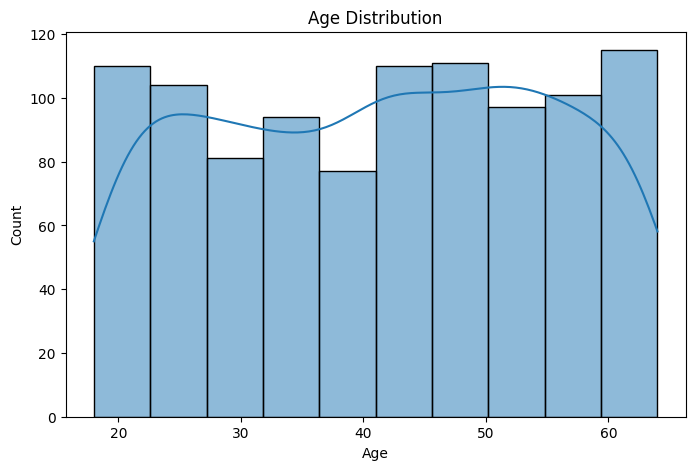

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=10, kde=True)

plt.title('Age Distribution')

plt.show()


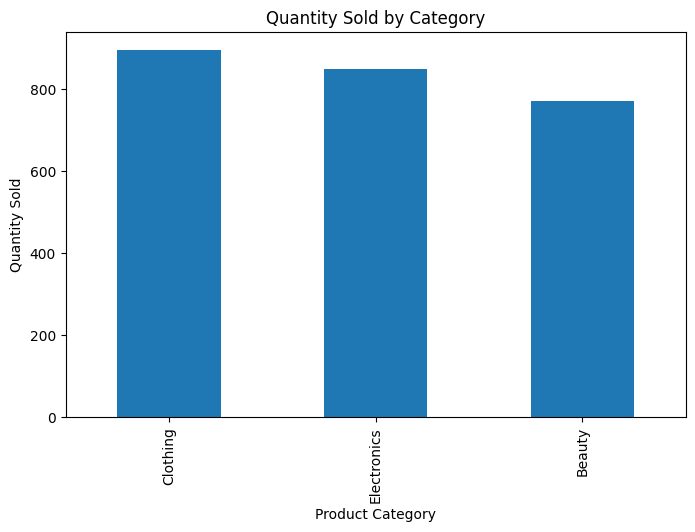

In [9]:
top_products = (
    df.groupby('Product Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

top_products.plot(kind='bar')

plt.title('Quantity Sold by Category')
plt.ylabel('Quantity Sold')

plt.show()

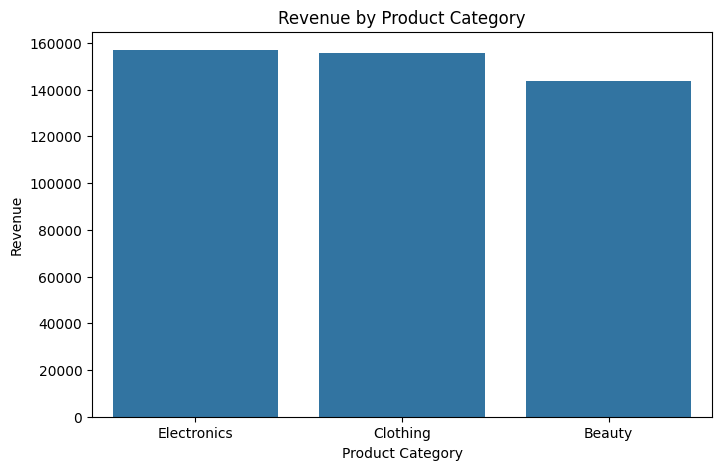

In [10]:
category_revenue = (
    df.groupby('Product Category')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title('Revenue by Product Category')
plt.ylabel('Revenue')

plt.show()

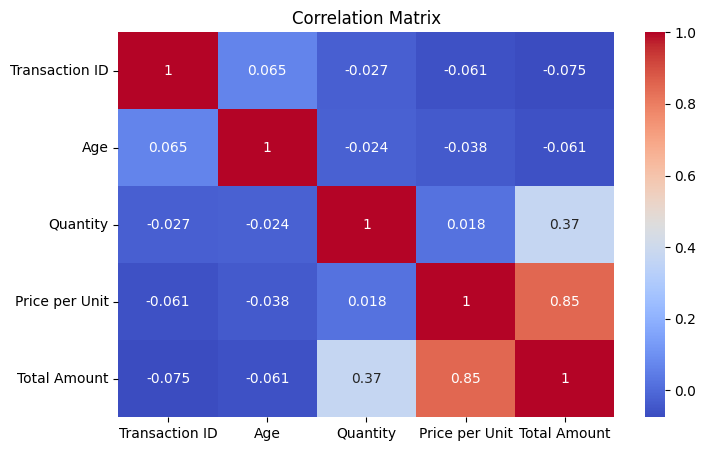

In [11]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

/tmp/ipykernel_2455/4134596599.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby('Age Group')['Total Amount'].sum()


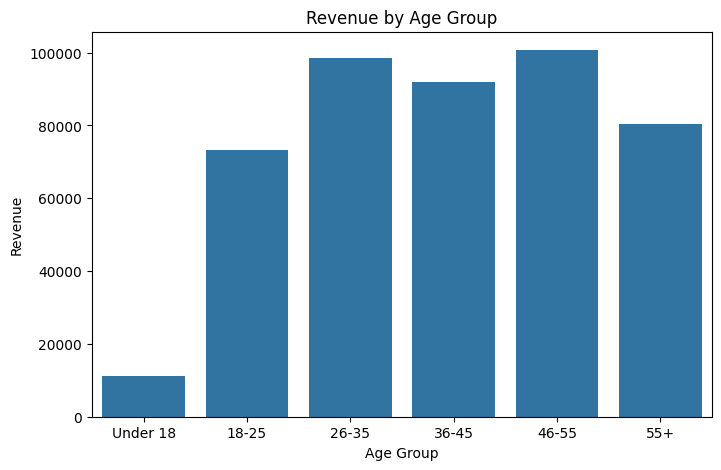

In [12]:
bins = [0,18,25,35,45,55,100]

labels = [
    'Under 18',
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '55+'
]

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

age_sales = df.groupby('Age Group')['Total Amount'].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=age_sales.index,
    y=age_sales.values
)

plt.title('Revenue by Age Group')
plt.ylabel('Revenue')

plt.show()